# Quarterly Average Returns by Sectors

This notebook shows the average quartely return for every sectors on the S&P 500.
It analysis historic data from different sectors and produces a report on their average quarterly returns.
This analysis goes through the last 5-10yrs of data.

In [1]:
%config IPCompleter.greedy=True

import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Setting the theme for charting

In [2]:
sns.set_theme(palette="pastel", style="white")

In [3]:
columns = ["Q1", "Q2", "Q3", "Q4"]

**Calculates the avg retutns by quarter.**

In [4]:
def quater(data):
    
    columns = ["Q1", "Q2", "Q3", "Q4"]
    
    sorted_data = {
        "Q1": [],
        "Q2": [],
        "Q3": [],
        "Q4": [],
    }
    
    for i, change in enumerate(data['ChangePct']):
        
        sorted_data[columns[i%4]].append(change)
        
    df = pd.DataFrame(sorted_data, columns=columns)
    
    return df

**Plots the avg returns by quarter.**

In [5]:
def plot(ticker: str, period: str, interval: str):
    
    ticker = yf.Ticker(ticker)
    data = ticker.history(period=period, interval=interval, auto_adjust=False, actions=False)
    
    data = data.dropna()
    
    # Drops the last row to clean up the data.
    data = data[:-1]
    
    data["Change"] = data['Close'] - data['Open']
    data["ChangePct"] = ((data['Change']) / data['Open']) * 100
    
    df = quater(data)
    
    avg_df = df.mean()
    
    xpos = plt.np.arange(len(avg_df))
    plt.xticks(xpos, columns)

    chart = plt.bar(xpos, avg_df[0:], color ='#d65c49', width = 0.4)

    for i, change in enumerate(avg_df[0:]):
        
        #Set color to green if the value is positive.
        if change > 0:
            chart[i].set_color("#6bdb89")

## XLK

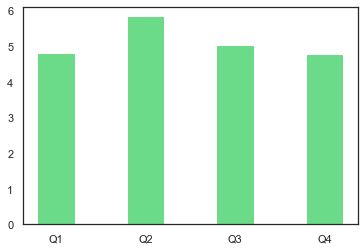

In [6]:
plot("XLK", "10y", "3mo")

## XLP

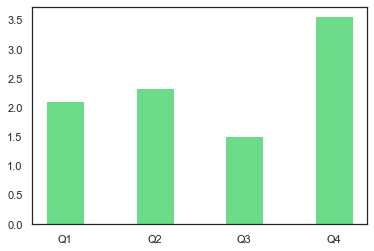

In [7]:
plot("XLP", "10y", "3mo")

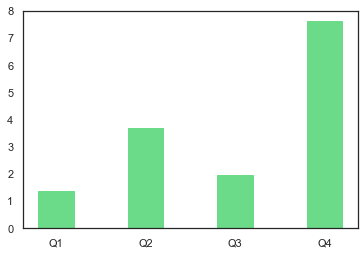

In [8]:
plot("XLF", "10y", "3mo")

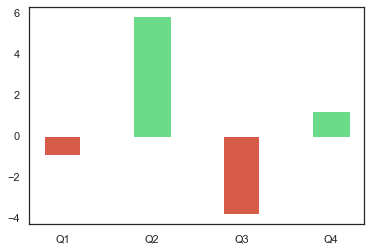

In [9]:
plot("XLE", "10y", "3mo")

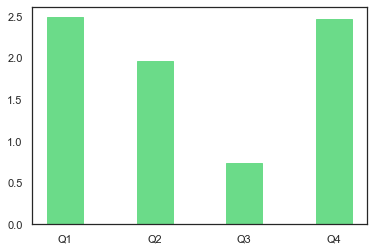

In [10]:
plot("XLU", "10y", "3mo")

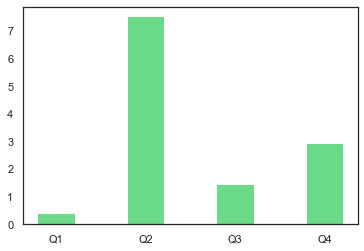

In [11]:
plot("XLRE", "5y", "3mo")

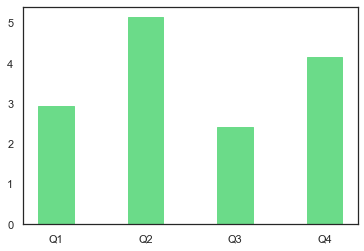

In [12]:
plot("XLV", "10y", "3mo")

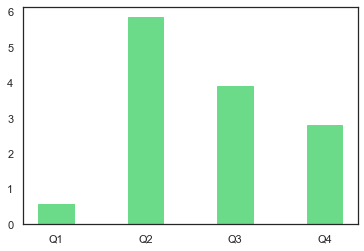

In [13]:
plot("XLI", "5y", "3mo")

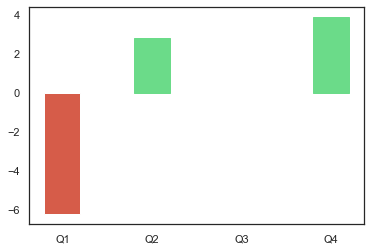

In [14]:
plot("JETS", "5y", "3mo")

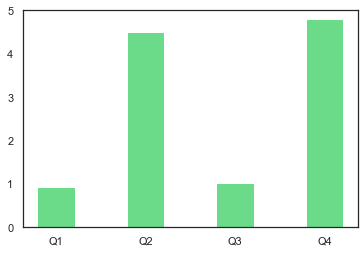

In [15]:
plot("XLB", "10y", "3mo")

## XLC Returns

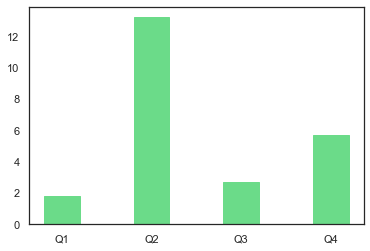

In [16]:
plot("XLC", "3y", "3mo")

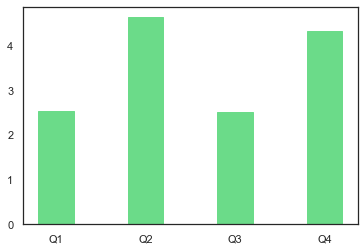

In [17]:
plot("SPY", "10y", "3mo")

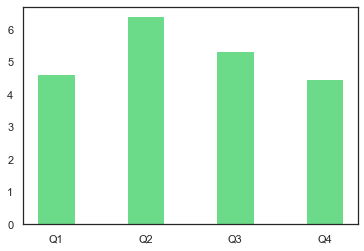

In [18]:
plot("QQQ", "10y", "3mo")

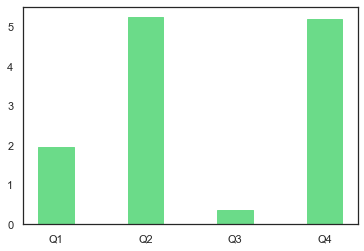

In [19]:
plot("IWM", "10y", "3mo")

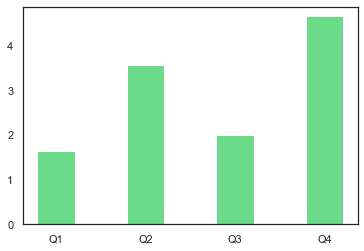

In [20]:
plot("DIA", "10y", "3mo")

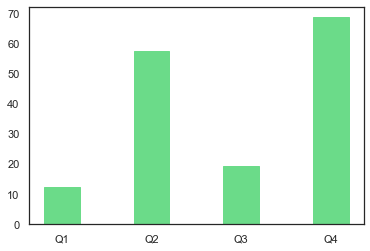

In [26]:
plot("BTC-USD", "5y", "3mo")